# DocVQA QA Benchmark Evaluation

Comprehensive evaluation of OCR and Question Answering (QA) performance on the DocVQA mini dataset.

## Pipeline Overview

**QA Phases (8 total):**
- **QA-OCR_LLM_simple/c/detailed/cot**: OCR Pipeline (Extract text via OCR → Answer QA based on extracted text)
  - QA-OCR_LLM_simple: Simple prompts
  - QA-OCR_LLM_detailed: Detailed prompts with context
  - QA-OCR_LLM_cot: Chain-of-Thought prompting
  
- **QA-VLM_LLM_simple/c/detailed/cot**: VLM Parse Pipeline (Parse document with VLM → Answer QA based on parsed output)
  - QA-VLM_LLM_simple: Simple prompts
  - QA-VLM_LLM_detailed: Detailed prompts
  - QA-VLM_LLM_cot: Chain-of-Thought prompting
  
- **QA-VLM_direct_simple/detailed**: Direct VQA (VLM answers directly from image)
  - QA-VLM_direct_simple: Simple prompts
  - QA-VLM_direct_detailed: Chain-of-Thought prompting

**Models Evaluated:**
- OCR: `azure_intelligence`, `mistral_document_ai`
- VLM: `gpt-5-mini`, `gpt-5-nano`
- QA: `gpt-5-mini`

## 1. Setup and Data Loading

## 📊 Data Preview

Quick look at 10 random samples showing ground truth vs model predictions.

In [ ]:
# ============================================================================
# DATA PREVIEW: Ground Truth vs Predictions (10 Random Samples)
# ============================================================================

# Load one phase to show examples
phase_to_preview = 'QA1a'
dataset_name = 'DocVQA_mini'

preview_file = f"../../../2_clean/{dataset_name}/{phase_to_preview}.csv"

if Path(preview_file).exists():
    df_preview = pd.read_csv(preview_file)

    # Get 10 random samples
    random_samples = df_preview.sample(n=min(10, len(df_preview)), random_state=42)

    # Extract columns for preview
    columns_to_show = ['sample_id', 'question', 'ground_truths']

    # Add prediction columns (find all columns starting with 'prediction_')
    pred_cols = [col for col in df_preview.columns if col.startswith('prediction_')]
    columns_to_show.extend(pred_cols[:2])  # Show first 2 models

    # Create display dataframe
    display_df = random_samples[columns_to_show].copy()

    # Truncate long strings for readability
    for col in display_df.columns:
        if display_df[col].dtype == 'object':
            display_df[col] = display_df[col].apply(
                lambda x: str(x)[:100] + '...' if pd.notna(x) and len(str(x)) > 100 else x
            )

    print(f"\n{'='*100}")
    print(f"DATA PREVIEW: {dataset_name} - {phase_to_preview}")
    print(f"Showing 10 random samples with ground truth and first 2 model predictions")
    print(f"{'='*100}\n")

    display(display_df)

    print(f"\nTotal samples in {phase_to_preview}: {len(df_preview)}")
    print(f"Available models: {', '.join([col.replace('prediction_', '') for col in pred_cols])}")
else:
    print(f"Preview file not found: {preview_file}")

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
import sys
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Setup plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully!")

In [ ]:
DATASET = "DocVQA_mini"
DATA_DIR = Path("../../../2_clean") / DATASET

# Define phases and their descriptions
PHASES = {
    "QA1a": "OCR Pipeline - Simple Prompts (azure_intelligence + mistral)",
    "QA1b": "OCR Pipeline - Detailed Prompts (azure_intelligence + mistral)",
    "QA1c": "OCR Pipeline - Chain-of-Thought (azure_intelligence + mistral)",
    "QA2a": "VLM Parse Pipeline - Simple (gpt-5-mini + gpt-5-nano)",
    "QA2b": "VLM Parse Pipeline - Detailed (gpt-5-mini + gpt-5-nano)",
    "QA2c": "VLM Parse Pipeline - Chain-of-Thought (gpt-5-mini + gpt-5-nano)",
    "QA3a": "Direct VQA - Simple (gpt-5-mini + gpt-5-nano)",
    "QA3b": "Direct VQA - Chain-of-Thought (gpt-5-mini + gpt-5-nano)",
}

# Phase groupings
APPROACH_GROUPS = {
    "OCR Pipeline": ["QA1a", "QA1b", "QA1c"],
    "VLM Parse Pipeline": ["QA2a", "QA2b", "QA2c"],
    "Direct VQA": ["QA3a", "QA3b"],
}

print(f"Dataset: {DATASET}")
print(f"Data Directory: {DATA_DIR}")
print(f"Phases to analyze: {len(PHASES)}")
for phase, desc in PHASES.items():
    print(f"  - {phase}: {desc}")

In [ ]:
# Extract models from all phases
all_models = set()
for phase in all_results.keys():
    df = all_results[phase]
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    all_models.update(models)

print("All models across phases:")
for model in sorted(all_models):
    print(f"  - {model}")

In [ ]:
# Load all phase CSV files
all_results = {}
for phase in PHASES.keys():
    phase_file = DATA_DIR / f"{phase}.csv"
    if not phase_file.exists():
        print(f"⚠ Phase {phase} file not found at {phase_file}")
        continue
    
    df = pd.read_csv(phase_file)
    all_results[phase] = df
    
    # Extract model names from column names (prediction_* columns)
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    
    print(f"✓ Phase {phase}: {len(df)} samples, {len(models)} models: {', '.join(models)}")

print(f"\n✓ Loaded results for {len(all_results)} phases")

## 2. OCR Evaluation Metrics

In [ ]:
def analyze_extracted_text(df: pd.DataFrame, model_name: str) -> Dict:
    """Analyze OCR extraction quality from extracted_text column for a specific model."""
    extracted_col = f'extracted_text_{model_name}'
    
    if extracted_col not in df.columns:
        return None
    
    results = {
        'total_samples': len(df),
        'samples_with_text': (df[extracted_col].notna() & (df[extracted_col] != '')).sum(),
        'empty_extractions': (df[extracted_col].isna() | (df[extracted_col] == '')).sum(),
        'avg_text_length': df[extracted_col].fillna('').apply(lambda x: len(str(x))).mean(),
        'median_text_length': df[extracted_col].fillna('').apply(lambda x: len(str(x))).median(),
    }
    results['extraction_success_rate'] = results['samples_with_text'] / results['total_samples']
    return results

# Analyze OCR extraction for QA1 phases (OCR Pipeline)
print("OCR Extraction Analysis (QA1 phases - OCR Pipeline)")
print("=" * 70)
ocr_phases = ["QA1a", "QA1b", "QA1c"]
ocr_analysis = {}

for phase in ocr_phases:
    if phase not in all_results:
        continue
    df = all_results[phase]
    
    print(f"\n{phase}:")
    
    # Find OCR models (those with extracted_text columns)
    extracted_cols = [col for col in df.columns if col.startswith('extracted_text_')]
    ocr_models = [col.replace('extracted_text_', '') for col in extracted_cols]
    
    for model in ocr_models:
        analysis = analyze_extracted_text(df, model)
        if analysis:
            ocr_analysis[f"{phase}_{model}"] = analysis
            print(f"  {model}:")
            print(f"    Total samples: {analysis['total_samples']}")
            print(f"    Successful extractions: {analysis['samples_with_text']} ({analysis['extraction_success_rate']*100:.1f}%)")
            print(f"    Avg text length: {analysis['avg_text_length']:.0f} chars")
            print(f"    Median text length: {analysis['median_text_length']:.0f} chars")

## 3. OCR Performance Analysis

In [ ]:
# Analyze which OCR models appear in each QA1 phase
print("\nOCR Models in QA1 Phases:")
print("=" * 70)
for phase in ocr_phases:
    if phase not in all_results:
        continue
    df = all_results[phase]
    
    # Extract OCR model names
    extracted_cols = [col for col in df.columns if col.startswith('extracted_text_')]
    ocr_models = [col.replace('extracted_text_', '') for col in extracted_cols]
    
    print(f"\n{phase}:")
    for model in sorted(ocr_models):
        print(f"  {model}: {len(df)} samples")

## 4. QA Evaluation Metrics

In [ ]:
# Extract QA metrics from consolidated CSVs (metrics already computed!)
print("QA Performance Metrics from Consolidated Data")
print("=" * 80)

qa_metrics = []
for phase, desc in PHASES.items():
    if phase not in all_results:
        continue
    
    df = all_results[phase]
    
    # Find all models in this phase (from prediction_* columns)
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    
    # For each model, extract the average metrics
    for model in models:
        anls_col = f'anls_score_{model}'
        em_col = f'exact_match_{model}'
        
        if anls_col in df.columns and em_col in df.columns:
            qa_metrics.append({
                'Phase': phase,
                'Model': model,
                'Description': desc,
                'ANLS': df[anls_col].mean(),
                'Exact Match': df[em_col].mean(),
                'Total Samples': len(df),
                'Valid Samples': df[anls_col].notna().sum(),
            })

qa_df = pd.DataFrame(qa_metrics)
print("\nAll Phase-Model Combinations:")
print(qa_df.to_string(index=False))

In [ ]:
# Aggregate metrics by phase (average across all models in phase)
print("\nAggregate Metrics by Phase:")
print("=" * 80)

phase_metrics = []
for phase in PHASES.keys():
    if phase not in all_results:
        continue
    
    df = all_results[phase]
    
    # Find all anls and em columns
    anls_cols = [col for col in df.columns if col.startswith('anls_score_')]
    em_cols = [col for col in df.columns if col.startswith('exact_match_')]
    
    if anls_cols and em_cols:
        # Average across all models
        avg_anls = df[anls_cols].mean().mean()
        avg_em = df[em_cols].mean().mean()
        
        phase_metrics.append({
            'Phase': phase,
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Num Models': len(anls_cols),
            'Samples': len(df)
        })

phase_df = pd.DataFrame(phase_metrics)
print(phase_df.to_string(index=False))

# Store for visualizations
comprehensive_df = phase_df

In [ ]:
# Visualize metrics comparison
if len(comprehensive_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('QA Evaluation Metrics Across All Phases', fontsize=16, fontweight='bold')
    
    # ANLS scores
    ax = axes[0]
    data = comprehensive_df.sort_values('ANLS', ascending=False)
    colors = plt.cm.RdYlGn(data['ANLS'])
    bars = ax.barh(range(len(data)), data['ANLS'], color=colors)
    
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data['Phase'], fontsize=8)
    ax.set_xlabel('ANLS Score', fontsize=10)
    ax.set_title('ANLS (Higher is Better)', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, data['ANLS'])):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
               f'{val:.3f}', va='center', fontsize=8)
    
    # Exact Match scores
    ax = axes[1]
    data = comprehensive_df.sort_values('Exact Match', ascending=False)
    colors = plt.cm.RdYlGn(data['Exact Match'])
    bars = ax.barh(range(len(data)), data['Exact Match'], color=colors)
    
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data['Phase'], fontsize=8)
    ax.set_xlabel('Exact Match Score', fontsize=10)
    ax.set_title('Exact Match (Higher is Better)', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, data['Exact Match'])):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
               f'{val:.3f}', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
else:
    print("No metrics available to visualize")

In [ ]:
# Group metrics by approach
print("\n\nPerformance by Approach:")
print("=" * 80)

approach_metrics = []
for approach, phases in APPROACH_GROUPS.items():
    valid_phases = [p for p in phases if p in comprehensive_df['Phase'].values]
    if not valid_phases:
        continue
    
    approach_data = comprehensive_df[comprehensive_df['Phase'].isin(valid_phases)]
    
    approach_metrics.append({
        'Approach': approach,
        'Avg ANLS': approach_data['ANLS'].mean(),
        'Std ANLS': approach_data['ANLS'].std(),
        'Avg EM': approach_data['Exact Match'].mean(),
        'Std EM': approach_data['Exact Match'].std(),
        'Num Phases': len(valid_phases),
    })

approach_df = pd.DataFrame(approach_metrics)
print(approach_df.to_string(index=False))

# Store for later visualization
approach_metrics_data = approach_df

## 5. QA Performance Analysis

In [ ]:
# Analyze prompt effectiveness within OCR Pipeline
print("\n\nPrompt Variation Analysis within OCR Pipeline (QA1 phases):")
print("=" * 80)
ocr_qa_analysis = []
for phase in ["QA1a", "QA1b", "QA1c"]:
    if phase not in comprehensive_df['Phase'].values:
        continue
    
    phase_data = comprehensive_df[comprehensive_df['Phase'] == phase].iloc[0]
    ocr_qa_analysis.append({
        'Phase': phase,
        'Prompt Style': phase[-1].upper(),
        'ANLS': phase_data['ANLS'],
        'EM': phase_data['Exact Match'],
    })

ocr_qa_df = pd.DataFrame(ocr_qa_analysis)
if len(ocr_qa_df) > 0:
    print(ocr_qa_df.to_string(index=False))
    print(f"\nBest OCR prompt variant: {ocr_qa_df.loc[ocr_qa_df['ANLS'].idxmax(), 'Phase']} (ANLS: {ocr_qa_df['ANLS'].max():.4f})")

In [ ]:
# Analyze prompt effectiveness within VLM Parse Pipeline
print("\n\nPrompt Variation Analysis within VLM Parse Pipeline (QA2 phases):")
print("=" * 80)
vlm_qa_analysis = []
for phase in ["QA2a", "QA2b", "QA2c"]:
    if phase not in comprehensive_df['Phase'].values:
        continue
    
    phase_data = comprehensive_df[comprehensive_df['Phase'] == phase].iloc[0]
    vlm_qa_analysis.append({
        'Phase': phase,
        'Prompt Style': phase[-1].upper(),
        'ANLS': phase_data['ANLS'],
        'EM': phase_data['Exact Match'],
    })

vlm_qa_df = pd.DataFrame(vlm_qa_analysis)
if len(vlm_qa_df) > 0:
    print(vlm_qa_df.to_string(index=False))
    print(f"\nBest VLM Parse prompt variant: {vlm_qa_df.loc[vlm_qa_df['ANLS'].idxmax(), 'Phase']} (ANLS: {vlm_qa_df['ANLS'].max():.4f})")

In [ ]:
# Analyze Direct VQA variants
print("\n\nDirect VQA Analysis (QA3 phases):")
print("=" * 80)
direct_qa_analysis = []
for phase in ["QA3a", "QA3b"]:
    if phase not in comprehensive_df['Phase'].values:
        continue
    
    phase_data = comprehensive_df[comprehensive_df['Phase'] == phase].iloc[0]
    direct_qa_analysis.append({
        'Phase': phase,
        'Prompt Style': phase[-1].upper(),
        'ANLS': phase_data['ANLS'],
        'EM': phase_data['Exact Match'],
    })

direct_qa_df = pd.DataFrame(direct_qa_analysis)
if len(direct_qa_df) > 0:
    print(direct_qa_df.to_string(index=False))
    if len(direct_qa_df) > 1:
        print(f"\nBest Direct VQA variant: {direct_qa_df.loc[direct_qa_df['ANLS'].idxmax(), 'Phase']} (ANLS: {direct_qa_df['ANLS'].max():.4f})")

## 6. Approach Comparison & Key Findings

In [ ]:
print("APPROACH COMPARISON - Key Metrics")
print("=" * 80)

# Get best phase from each approach
best_by_approach = {}
for approach, phases in APPROACH_GROUPS.items():
    valid_phases = [p for p in phases if p in comprehensive_df['Phase'].values]
    if valid_phases:
        approach_data = comprehensive_df[comprehensive_df['Phase'].isin(valid_phases)]
        best_phase = approach_data.loc[approach_data['ANLS'].idxmax(), 'Phase']
        best_data = approach_data[approach_data['Phase'] == best_phase].iloc[0]
        
        best_by_approach[approach] = {
            'best_phase': best_phase,
            'anls': best_data['ANLS'],
            'em': best_data['Exact Match'],
        }

for approach, data in best_by_approach.items():
    print(f"\n{approach}")
    print(f"  Best phase: {data['best_phase']}")
    print(f"  ANLS: {data['anls']:.4f}")
    print(f"  Exact Match: {data['em']:.4f}")

# Overall best
if best_by_approach:
    best_overall = max(best_by_approach.items(), key=lambda x: x[1]['anls'])
    print(f"\n{'=' * 80}")
    print(f"OVERALL BEST: {best_overall[0]} (Phase: {best_overall[1]['best_phase']})")
    print(f"ANLS: {best_overall[1]['anls']:.4f} | EM: {best_overall[1]['em']:.4f}")

## 7. Visualizations & Summary

In [ ]:
# Create phase performance visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ANLS Scores
ax1 = axes[0]
phases = comprehensive_df['Phase'].values
anls_scores = comprehensive_df['ANLS'].values
colors = ['#FF6B6B' if p.startswith('QA1') else '#4ECDC4' if p.startswith('QA2') else '#95E1D3' for p in phases]

ax1.bar(phases, anls_scores, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('ANLS Score', fontsize=12, fontweight='bold')
ax1.set_title('ANLS Scores Across All Phases', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (phase, score) in enumerate(zip(phases, anls_scores)):
    ax1.text(i, score + 0.02, f'{score:.3f}', ha='center', va='bottom', fontsize=9)

# Exact Match Scores
ax2 = axes[1]
em_scores = comprehensive_df['Exact Match'].values

ax2.bar(phases, em_scores, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Exact Match Rate', fontsize=12, fontweight='bold')
ax2.set_title('Exact Match Scores Across All Phases', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, (phase, score) in enumerate(zip(phases, em_scores)):
    ax2.text(i, score + 0.02, f'{score:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Phase performance visualization complete")

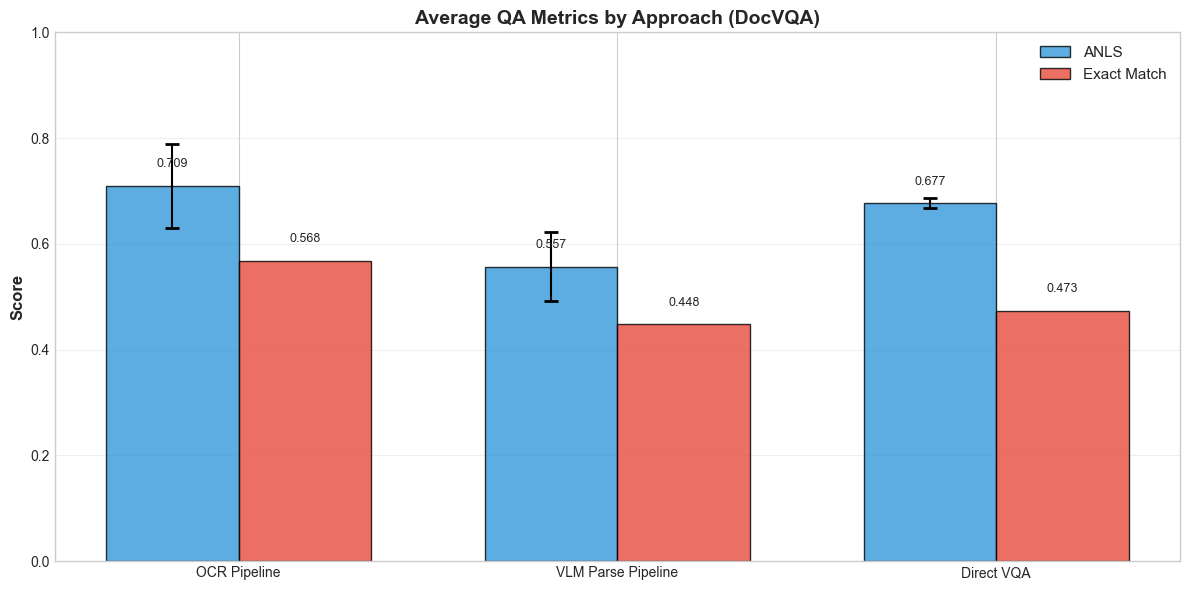


✓ Approach comparison visualization complete


In [55]:
# Approach comparison visualization
fig, ax = plt.subplots(figsize=(12, 6))

approaches = approach_metrics_data['Approach'].values
anls_avg = approach_metrics_data['Avg ANLS'].values
anls_std = approach_metrics_data['Std ANLS'].values

x = np.arange(len(approaches))
width = 0.35

bars = ax.bar(x, anls_avg, width, label='ANLS', color='#3498db', alpha=0.8, edgecolor='black')
ax.errorbar(x, anls_avg, yerr=anls_std, fmt='none', ecolor='black', capsize=5, capthick=2)

# Add EM scores as secondary
em_avg = approach_metrics_data['Avg EM'].values
ax.bar(x + width, em_avg, width, label='Exact Match', color='#e74c3c', alpha=0.8, edgecolor='black')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Average QA Metrics by Approach (DocVQA)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(approaches)
ax.legend(fontsize=11)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (anls, em) in enumerate(zip(anls_avg, em_avg)):
    ax.text(i, anls + 0.03, f'{anls:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width, em + 0.03, f'{em:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Approach comparison visualization complete")

In [ ]:
# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS - DocVQA Mini Dataset")
print("=" * 80)

all_anls = comprehensive_df['ANLS'].values
all_em = comprehensive_df['Exact Match'].values

print(f"\nANLS Scores across all {len(all_anls)} phases:")
print(f"  Mean:   {np.mean(all_anls):.4f}")
print(f"  Std:    {np.std(all_anls):.4f}")
print(f"  Min:    {np.min(all_anls):.4f}")
print(f"  Max:    {np.max(all_anls):.4f}")
print(f"  Median: {np.median(all_anls):.4f}")

print(f"\nExact Match Scores across all {len(all_em)} phases:")
print(f"  Mean:   {np.mean(all_em):.4f}")
print(f"  Std:    {np.std(all_em):.4f}")
print(f"  Min:    {np.min(all_em):.4f}")
print(f"  Max:    {np.max(all_em):.4f}")
print(f"  Median: {np.median(all_em):.4f}")

total_samples = comprehensive_df['Samples'].sum()
print(f"\nTotal samples processed: {total_samples} across {len(PHASES)} phases")